# Module 03: EDA

In [4]:
# packages
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split 
from ISLP import load_data

# set seed
seed = 2323

### We'll use the _Hitters_ data from ISLP for this activity. The metadata for _Hitters_ can be found [here](https://intro-stat-learning.github.io/ISLP/datasets/Hitters.html).

In [5]:
# Load the data
Hitters = load_data('Hitters')
Hitters

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


### Determine the number of rows and columns in the dataset by returning its "shape" attribute

In [6]:
#fillin
Hitters.shape

(322, 20)

### Determine whether each feature is numeric or categorical by returning the "dtype" attribute for each column

In [7]:
for col in Hitters.columns:
    print(Hitters[col].dtype)

int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
category
category
int64
int64
int64
float64
category


### Before doing any other analyses, let's create training and test sets.

In [37]:
Train, Test = train_test_split(Hitters, 
                               random_state=seed, 
                               test_size=0.40, 
                               shuffle=True) 
Train

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
63,216,53,1,31,15,22,4,926,210,9,118,69,114,N,W,73,152,11,225.0,N
27,474,129,10,50,56,40,10,2331,604,61,246,327,166,N,W,732,83,13,750.0,N
130,306,104,14,50,58,25,7,2954,822,55,313,377,187,N,E,116,222,15,750.0,N
93,511,138,25,76,96,61,3,592,164,28,87,110,71,A,W,157,7,8,145.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,480,112,18,50,71,44,7,3031,771,110,338,406,239,N,E,94,270,16,750.0,N
90,314,83,13,39,46,16,5,1457,405,28,156,159,76,A,W,533,40,4,431.5,A
147,599,183,10,80,74,32,5,2482,715,27,330,326,158,A,E,231,374,18,775.0,A
232,313,83,9,43,41,30,14,5885,1543,104,751,714,535,N,W,58,141,23,450.0,N


### Based on the metadata, what is the difference between the 6 columns starting with 'C' and the 6 related columns that don't?

Thee first 6 columns are the player's stats from the year 1986, the 6 columns starting with C are stats from the players career

### On the training set, create pairwise scatterplots for each of these 6 columns with the 'Salary' variable.

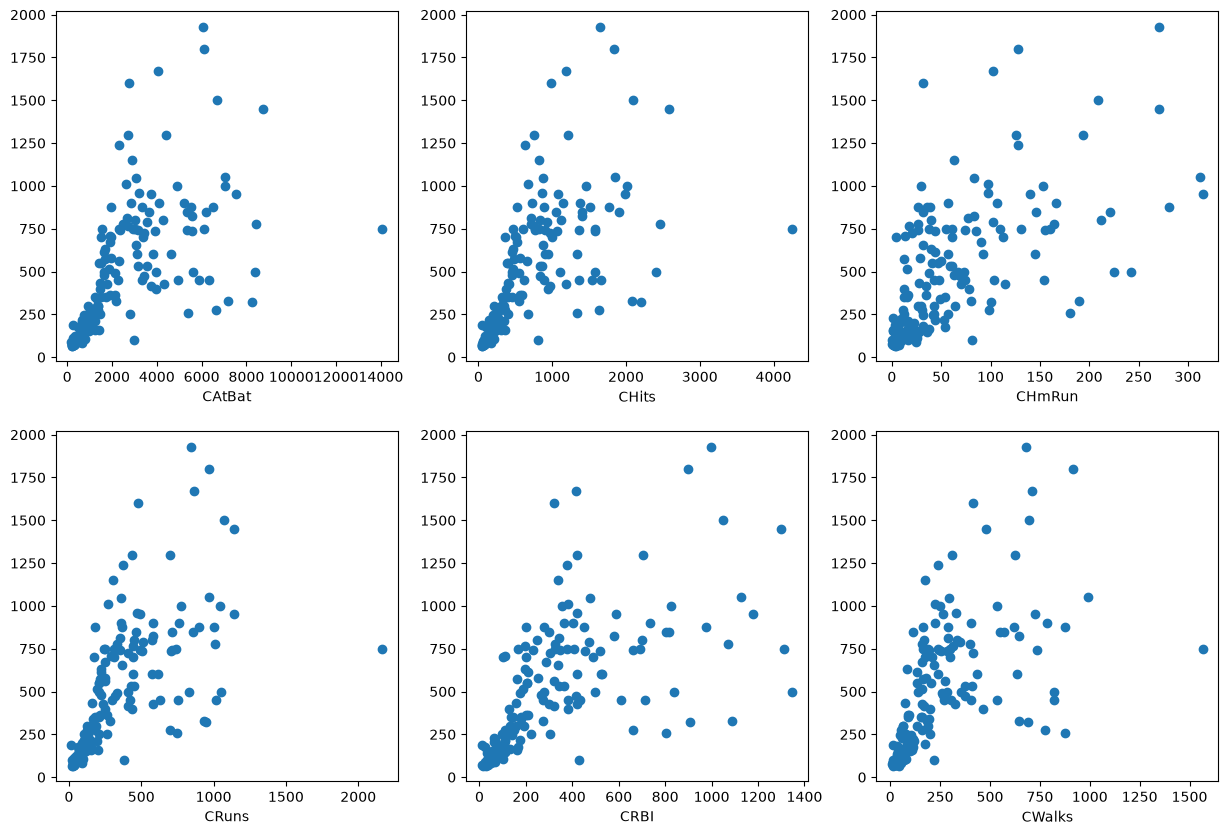

In [9]:
# First create a subset of the columns that we want to plot

subset = Train[['CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']]

# Initialize the plots before drawing them

fig, axes = subplots(nrows=2,
                     ncols=3,
                     figsize=(15, 10))
# Copy the helper function

def range_to_grid(i,Ncol):
    x=[]
    y=[]
    for n in range(Ncol**2):
        x.append(int(np.floor(n/Ncol)))
        y.append(n % Ncol)
        #print(n,x[n],y[n])
    return x[i],y[i]

# Plot the variables

for j in range(len(subset.columns)):
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].plot(subset.iloc[:,j], Train['Salary'], 'o')
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].set_xlabel(subset.columns[j])


### Use the "describe" method to determine the mean, standard deviation, and 5 number summary of all numeric variables in the training subset of _Hitters_.

In [10]:
Train.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,164.000000
mean,381.829016,101.549223,10.150259,50.751295,47.093264,38.445596,7.253886,2587.440415,702.222798,59.668394,345.378238,308.373057,248.388601,276.865285,105.300518,8.051813,493.032951
std,145.679181,44.267521,8.228711,24.784284,24.912589,21.136915,4.858712,2285.947344,649.010165,66.449102,322.848870,297.885894,250.777436,262.957701,137.135778,6.783667,386.159522
min,19.000000,7.000000,0.000000,1.000000,2.000000,1.000000,1.000000,41.000000,13.000000,0.000000,3.000000,4.000000,4.000000,0.000000,0.000000,0.000000,67.500000
25%,271.000000,68.000000,4.000000,32.000000,29.000000,22.000000,3.000000,730.000000,185.000000,14.000000,98.000000,82.000000,63.000000,109.000000,7.000000,3.000000,160.000000
50%,369.000000,95.000000,8.000000,47.000000,43.000000,34.000000,6.000000,1876.000000,476.000000,36.000000,238.000000,202.000000,166.000000,211.000000,38.000000,6.000000,420.833500
75%,508.000000,136.000000,14.000000,68.000000,61.000000,53.000000,11.000000,3754.000000,1000.000000,78.000000,494.000000,419.000000,332.000000,317.000000,173.000000,12.000000,750.000000
max,687.000000,223.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,315.000000,2165.000000,1348.000000,1566.000000,1320.000000,492.000000,32.000000,1925.571000


### It looks like the mean and median of 'AtBat' are nearly equal. This _might_ suggest that this variable is normally distributed. Create a histogram of 'AtBat' to check this hypothesis.

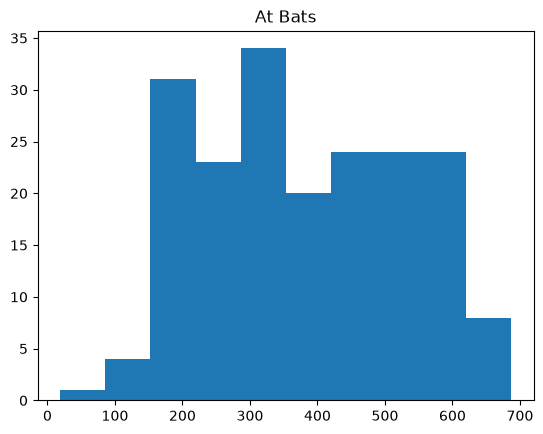

In [17]:
AtBat = Train["AtBat"]
histogram = plt.hist(AtBat, bins=10)
plt.title("At Bats")
plt.show()

### Let's standardize the AtBat feature (i.e., normalize by z-scores). We'll create a new column in the training data called 'AtBat_st' to represent this.

In [62]:
Train["AtBat_st"] = (AtBat - AtBat.mean()) / AtBat.std()
Train


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,League,Division,PutOuts,Assists,Errors,Salary,NewLeague,AVG_bin,AVG,AtBat_st
3,496,141,20,65,78,37,11,5628,1575,225,...,N,E,200,11,3,500.0,N,medium,0.284274,0.783715
63,216,53,1,31,15,22,4,926,210,9,...,N,W,73,152,11,225.0,N,low,0.245370,-1.138317
27,474,129,10,50,56,40,10,2331,604,61,...,N,W,732,83,13,750.0,N,medium,0.272152,0.632698
130,306,104,14,50,58,25,7,2954,822,55,...,N,E,116,222,15,750.0,N,high,0.339869,-0.520521
93,511,138,25,76,96,61,3,592,164,28,...,A,W,157,7,8,145.0,A,medium,0.270059,0.886681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,480,112,18,50,71,44,7,3031,771,110,...,N,E,94,270,16,750.0,N,low,0.233333,0.673885
90,314,83,13,39,46,16,5,1457,405,28,...,A,W,533,40,4,431.5,A,medium,0.264331,-0.465605
147,599,183,10,80,74,32,5,2482,715,27,...,A,E,231,374,18,775.0,A,medium,0.305509,1.490748
232,313,83,9,43,41,30,14,5885,1543,104,...,N,W,58,141,23,450.0,N,medium,0.265176,-0.472470


### How many rows have an 'AtBat' value within the first standard deviation?

Hint: the 'len' magic method returns the number of rows of a dataFrame.

In [63]:
len(Train["AtBat_st"][Train["AtBat_st"].abs() <= 1])

115

### Going back to the results of the 'describe' method, how can you tell that the 'Salary' variable has missing values?

The count is less than the total rows

### Describe a situation where a variable could have missing values but this would not be reflected in the results of the 'describe' method.

if a place holder was used like "none", then the count would remain the same but the mean, max, etc could be changed

### On the training data, create separate boxplots of the 'AtBat' variable for when 'Salary' is populated or missing.

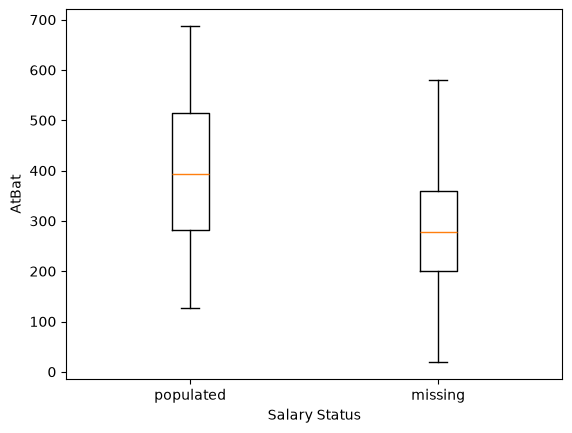

In [36]:
atbat_populated = Train.loc[Train['Salary'].notna(), 'AtBat']
atbat_missing = Train.loc[Train['Salary'].isna(), 'AtBat']

plt.boxplot([atbat_populated, atbat_missing], tick_labels=["populated", "missing"])
plt.xlabel('Salary Status')
plt.ylabel('AtBat')
plt.show()

### Create a correlation matrix for all numeric features in the training set

In [29]:
corr_matrix = Train.corr(numeric_only=True)
corr_matrix

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
AtBat,1.000000,0.963324,0.540323,0.906579,0.798717,0.631824,-0.039232,0.126602,0.146763,0.150166,0.164892,0.145779,0.056578,0.345879,0.363085,0.368162,0.401390
Hits,0.963324,1.000000,0.516853,0.914739,0.795316,0.605876,-0.028717,0.133316,0.163329,0.136865,0.175542,0.153011,0.065178,0.312858,0.310422,0.301725,0.432558
HmRun,0.540323,0.516853,1.000000,0.618439,0.840613,0.385425,0.009072,0.078981,0.076914,0.411917,0.110767,0.218285,0.080296,0.222084,-0.069088,0.062840,0.326021
Runs,0.906579,0.914739,0.618439,1.000000,0.786635,0.711346,-0.069584,0.083770,0.103859,0.160979,0.159683,0.115628,0.099025,0.289952,0.184714,0.217297,0.441499
RBI,0.798717,0.795316,0.840613,0.786635,1.000000,0.553527,0.046705,0.165837,0.180526,0.375072,0.191452,0.285074,0.117109,0.323825,0.138896,0.217983,0.414623
Walks,0.631824,0.605876,0.385425,0.711346,0.553527,1.000000,0.037943,0.137157,0.147019,0.194766,0.205250,0.167453,0.312812,0.317000,0.139008,0.160753,0.458462
Years,-0.039232,-0.028717,0.009072,-0.069584,0.046705,0.037943,1.000000,0.925308,0.906857,0.730478,0.882559,0.882835,0.836809,0.071301,-0.091915,-0.160476,0.541390
CAtBat,0.126602,0.133316,0.078981,0.083770,0.165837,0.137157,0.925308,1.000000,0.995185,0.775167,0.979705,0.948617,0.894573,0.120875,-0.000507,-0.068187,0.616677
CHits,0.146763,0.163329,0.076914,0.103859,0.180526,0.147019,0.906857,0.995185,1.000000,0.761920,0.983128,0.945002,0.883547,0.132818,-0.003372,-0.062669,0.629875
CHmRun,0.150166,0.136865,0.411917,0.160979,0.375072,0.194766,0.730478,0.775167,0.761920,1.000000,0.782490,0.912134,0.750795,0.126756,-0.129640,-0.141514,0.616170


### Propose two different ways of imputing the missing values of Salary while taking advantage of the information given in the boxplots or the correlation matrix.

We could use the correlation matrix values to fill in the missing values of salary depending on the highest correlation value? It looks like Career runs has the highest correlation with salary so using a linear chart of salary to Career runs could be used to find possible missing values?

using the boxplot information we could guess on what the missing salary values should be. For the atbat information from the boxplot we see that the missing data is less.

### For our last exercise, we'll explore Hits and Walks relative to AtBat totals. 
- Use the sum function to calculuate the totals of each of these three variables for the 1986 season (on the training set). 
- Create a pie chart which shows total hits, total walks, and remaining total (neither) as percents of the At Bats total (on the training set). 

In [39]:
TotHits = Train['Hits'].sum()
TotWalks = Train['Walks'].sum()
TotAtBat = Train['AtBat'].sum()

Labels = ['Hits', 'Walks', 'Neither']
Totals = [TotHits, TotWalks, TotAtBat-TotHits-TotWalks]

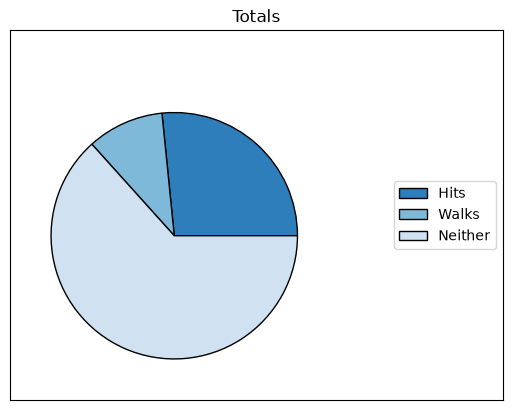

In [46]:

colors = plt.get_cmap('Blues')(np.linspace(0.7, 0.2, len(Totals)))

# Create a figure and axes
fig, ax = plt.subplots()

# Create the pie chart
ax.pie(Totals, colors=colors, radius=3, center=(4, 4),
       wedgeprops={"linewidth": 1, "edgecolor": "black"}, frame=True)

# Include a legend
ax.legend(Labels, loc="right")

# Adjust the axes
ax.set(xlim=(0, 12), xticks=np.arange(1, 8),
       ylim=(0, 9), yticks=np.arange(1, 8))
ax.tick_params(left = False, labelleft = False, 
               bottom = False, labelbottom = False)
ax.set(title="Totals")

plt.show()


### The previous two cells gave us totals across all players. For each player in the training set, calculate the Hits as a percent of AtBat and store it in a new variable called 'AVG'

In [61]:
Train["AVG"] = (Train['Hits'] / Train['AtBat'])
Train

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague,AVG_bin,AVG
3,496,141,20,65,78,37,11,5628,1575,225,...,354,N,E,200,11,3,500.0,N,medium,0.284274
63,216,53,1,31,15,22,4,926,210,9,...,114,N,W,73,152,11,225.0,N,low,0.245370
27,474,129,10,50,56,40,10,2331,604,61,...,166,N,W,732,83,13,750.0,N,medium,0.272152
130,306,104,14,50,58,25,7,2954,822,55,...,187,N,E,116,222,15,750.0,N,high,0.339869
93,511,138,25,76,96,61,3,592,164,28,...,71,A,W,157,7,8,145.0,A,medium,0.270059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,480,112,18,50,71,44,7,3031,771,110,...,239,N,E,94,270,16,750.0,N,low,0.233333
90,314,83,13,39,46,16,5,1457,405,28,...,76,A,W,533,40,4,431.5,A,medium,0.264331
147,599,183,10,80,74,32,5,2482,715,27,...,158,A,E,231,374,18,775.0,A,medium,0.305509
232,313,83,9,43,41,30,14,5885,1543,104,...,535,N,W,58,141,23,450.0,N,medium,0.265176


### Using 0.25 and 0.31 as the split points, create a new variable with three bins: high, medium, and low. 

In [64]:
Train['AVG_bin'] = 'medium'
Train.loc[Train["AVG"] <= 0.25, 'AVG_bin'] = 'low'
Train.loc[Train["AVG"] > 0.31, 'AVG_bin'] = 'high'

### Create a bar chart that displays the number of players in each of the low, medium, and high categories (for the training data).

In [65]:
Train['AVG_bin'].value_counts()

AVG_bin
medium    110
low        69
high       14
Name: count, dtype: int64

Notice that the order of the bars will be medium, low, high. That's counterintuitive. We can reorder these quickly. 

In [66]:
indexMap = ['low', 'medium', 'high']
reordered_list = [Train['AVG_bin'].value_counts()[i] for i in indexMap]

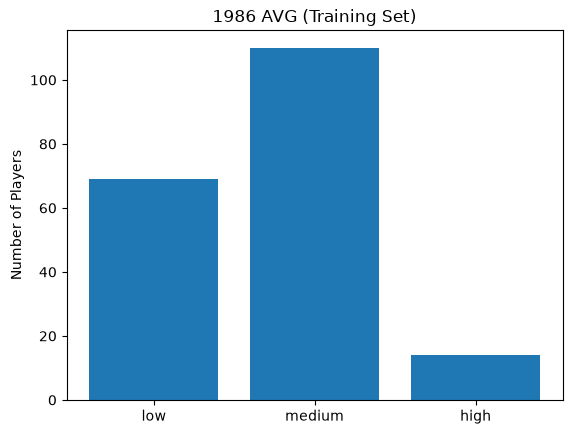

In [67]:
plt.bar(range(len(indexMap)), reordered_list)

plt.title("1986 AVG (Training Set)")
plt.ylabel("Number of Players")

plt.xticks(range(len(indexMap)), indexMap)

plt.show()

### Did we use the depth method or width method for creating these bins? Explain.

We used width method, if we used depth method the number of players in each bin would be the same, and instead of counting the number of players we used a numerical amount to separate them, leading to the bins being uneven, but giving us better information.